# 1) Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression


In [2]:
df_ventes = pd.read_csv('data/ech_annonces_ventes_68.csv', sep=';', index_col='idannonce')

# 2) Nettoyage et conversion de float à int

In [3]:
def clean_df(df: pd.DataFrame):
    # On supprime les colonnes ayant plus de 80% de valeurs manquantes
    valeurs_manquantes = df.isna().sum()/df.shape[0]
    valeurs_manquantes_list = list(valeurs_manquantes[valeurs_manquantes > 0.8].index)
    df_filtered = df.drop(valeurs_manquantes_list, axis = 1)
    # On supprime les colonnes "n6" pour ne laisser que les "n7" qui paraissent plus judicieuses (basées sur un plus grand nombre de bien)
    column_n6 = [ column for column in df_filtered.columns if "n6" in column]
    df_filtered = df_filtered.drop(column_n6, axis = 1)
    if 'typedebien' in df_filtered.columns:
        df_filtered = df_filtered[df_filtered['typedebien'] != 'l']
        df_filtered['typedebien'] = df_filtered['typedebien'].replace({'an': 'a', 'mn': 'm'})

    # On transform en Int des colonnes déclarées en float mais n'ayant que des int
    valeurs_manq_resid_quanti = [col for  col in df_filtered.select_dtypes(exclude='object').columns if df_filtered[col].isna().sum() > 0]    
    col_float = df_filtered[valeurs_manq_resid_quanti].select_dtypes(include='float64').columns
    for col in col_float:
        array_col = np.array(df_filtered[df_filtered[col].notna()][col]) 
        array_col_round = np.round(array_col)
        array_real_float = array_col[array_col != array_col_round]
        if len(array_real_float) == 0:
            df_filtered[col] = df_filtered[col].astype('Int64')
    # on transforme les colonnes quali n'ayant en fait que deux modalités
    if 'cave' in df_filtered.columns:
        df_filtered["cave"] = df_filtered["cave"].astype('Int64')
    if 'ascenseur' in df_filtered.columns:
        df_filtered["ascenseur"] = df_filtered["ascenseur"].astype('Int64')
    if 'logement_neuf' in df_filtered.columns:
        df_filtered["logement_neuf"] = df_filtered["logement_neuf"].replace({'n': False, 'o': True}).astype('Int64')

    return df_filtered

In [4]:
df_ventes = clean_df(df_ventes)
target = df_ventes['prix_bien']

# 3) Split train/test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df_ventes.drop(columns=['prix_bien']),
    target,
    test_size=0.2,
    random_state=42
)

# 4) Transformer pour le remplissage (quali et quanti) du dataframe

In [6]:
class KNNImputerCustom(BaseEstimator, TransformerMixin):
    def __init__(self, type_col="typedebien", lat_col="mapCoordonneesLatitude", lon_col="mapCoordonneesLongitude", pieces_col="nb_pieces", k=10):
        self.type_col = type_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.pieces_col = pieces_col
        self.k = k
        self.fitted = False
 
    def fit(self, X, y=None):
        self.df_train_ = X.copy()
        self.numeric_cols_ = X.select_dtypes(exclude="object").columns.tolist()
        self.default_mean_ = {col: X[col].mean() for col in self.numeric_cols_}
        self.imputer_ = KNNImputer()
        self.quali_cols_ = X.select_dtypes(include="object").columns.tolist()
        self.default_mode_ = {col: X[col].mode()[0] for col in self.quali_cols_}
        self.fitted = True
        
        return self
 
    def transform(self, X):
        if not(self.fitted):
            raise NotFittedError("This KNNImputerCustomed instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.")
        X = X.copy()
        # First we fill the numeric columns
        for col in self.numeric_cols_:
            if X[col].isna().sum() == 0:
                continue
            cols = [col, self.pieces_col, self.lat_col, self.lon_col]
            df_extract = X[[self.type_col] + cols]
            df_extract_train = self.df_train_ [[self.type_col] + cols]
            for typ in ["a", "m"]:
                subset = df_extract[df_extract[self.type_col] == typ][cols]
                if subset.shape[0] == 0:
                    continue
                apply_default = True
                subset_train = df_extract_train[df_extract_train[self.type_col] == typ][cols]
                if subset_train.shape[0] != 0:
                    self.imputer_.fit(subset_train)
                    imputed = self.imputer_.transform(subset)
                    if imputed.shape[1] == len(cols):
                        imputed_df = pd.DataFrame(imputed, columns=cols, index=subset.index)
                        apply_default = False
                if apply_default:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[subset.index, col] = self.default_mean_[col].astype("int64")
                    else:
                        X.loc[subset.index, col] = self.default_mean_[col]
                else:
                    if X[col].dtype in ["int64", "Int64"]:
                        X.loc[imputed_df.index, col] = imputed_df[col].round().astype("int64")
                    else:
                        X.loc[imputed_df.index, col] = imputed_df[col]

        #Secondly we fill the qualitative columns
        index_na = X[X[self.quali_cols_].isna().any(axis=1)].index
        for idx in index_na:
            lat = X.loc[idx, self.lat_col]
            lon = X.loc[idx, self.lon_col]
            nbp = X.loc[idx, self.pieces_col]
            typ = X.loc[idx, self.type_col]
            neighbours = self.df_train_[
                (self.df_train_[self.pieces_col] == nbp) &
                (self.df_train_[self.type_col] == typ)
            ]
            distances = (lat - neighbours[self.lat_col])**2 + (lon - neighbours[self.lon_col])**2
            for col in self.quali_cols_:
                if pd.isna(X.loc[idx, col]):
                    valid = neighbours[neighbours[col].notna()]
                    if valid.shape[0] > 0:
                        idx_neigh = distances[valid.index].sort_values().iloc[:self.k].index
                        X.loc[idx, col] = neighbours.loc[idx_neigh][col].mode()[0]
                    else:
                        X.loc[idx, col] = self.default_mode_[col]
        
        return X

In [7]:
knn_imputer_custom = KNNImputerCustom()
X_train = knn_imputer_custom.fit_transform(X_train)
X_test = knn_imputer_custom.transform(X_test)

# 5) Fonction de nettoyage des outiliers (IQR)

In [8]:
# Suppression de certains champs dont nous ne connaissons pas la définition
X_train.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)
X_test.drop(columns=['duree_int', 'loyer_m2_median_n7', 'nb_log_n7', 'taux_rendement_n7'], axis=1, inplace=True)

In [9]:
X_train_clean = X_train

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_train[col].quantile(0.1), 0)
    q3 = max(X_train[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_train[(X_train[col] < lower) | (X_train[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_train_clean = X_train_clean.drop(index_to_drop)

nb_rows_avant = X_train.shape[0]
nb_rows_apres = X_train_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_train = X_train_clean
y_train = y_train.loc[X_train.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 272  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  421.0  ( 105  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2850.0  ( 351  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 47  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 331  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 3  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 16  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 89  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  745.8  ( 13  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.595870000000005  ou  mapCoordonneesLatitude  >  49.07131999999999  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.43378  ou  mapCoordonneesLongitude  >  8.263480000000001  ( 0  rows)
Suppression des lignes où  nb_etages 

In [10]:
X_test_clean = X_test

numeric_cols = X_test.select_dtypes(include=['number']).columns.tolist()

index_to_drop = []

for col in numeric_cols:
    q1 = max(X_test[col].quantile(0.1), 0)
    q3 = max(X_test[col].quantile(0.9), 0)
    iqr = q3 - q1
    lower = max(q1 - 2 * iqr, 0)
    upper = max(q3 + 2 * iqr, 0)
    temp_index_to_drop = X_test[(X_test[col] < lower) | (X_test[col] > upper)].index.to_list()
    index_to_drop.extend(temp_index_to_drop)
    print("Suppression des lignes où ", col , " < ", lower, " ou ", col, " > ", upper, " (", len(temp_index_to_drop), " rows)")

X_test_clean = X_test_clean.drop(index_to_drop)

nb_rows_avant = X_test.shape[0]
nb_rows_apres = X_test_clean.shape[0]
nb_rows_suppr = nb_rows_avant - nb_rows_apres

print("\ndataframe initial : ", nb_rows_avant, " rows.")
print("dataframe nettoyé avec iqr : ", nb_rows_apres, " rows.")
print("Proportion conservé : ", 100 * np.round(nb_rows_apres/nb_rows_avant, 5), "%")
print("Nombre d'observations supprimées : ", nb_rows_suppr)

X_test = X_test_clean
y_test = y_test.loc[X_test.index]

Suppression des lignes où  etage  <  0  ou  etage  >  6.0  ( 85  rows)
Suppression des lignes où  surface  <  0  ou  surface  >  430.0  ( 26  rows)
Suppression des lignes où  surface_terrain  <  0  ou  surface_terrain  >  2857.5868  ( 85  rows)
Suppression des lignes où  nb_pieces  <  0  ou  nb_pieces  >  17.0  ( 12  rows)
Suppression des lignes où  mensualiteFinance  <  0.0  ou  mensualiteFinance  >  0.0  ( 88  rows)
Suppression des lignes où  balcon  <  0  ou  balcon  >  3.0  ( 1  rows)
Suppression des lignes où  eau  <  0  ou  eau  >  3.0  ( 4  rows)
Suppression des lignes où  bain  <  0  ou  bain  >  3.0  ( 22  rows)
Suppression des lignes où  dpeC  <  0  ou  dpeC  >  748.9800000000002  ( 3  rows)
Suppression des lignes où  mapCoordonneesLatitude  <  46.59563  ou  mapCoordonneesLatitude  >  49.07168  ( 0  rows)
Suppression des lignes où  mapCoordonneesLongitude  <  6.445864  ou  mapCoordonneesLongitude  >  8.251978999999999  ( 0  rows)
Suppression des lignes où  nb_etages  <  0  ou

# 6) Normalisation des données GPS (fit sur train)

In [11]:
scaler_lat = StandardScaler()
scaler_lon = StandardScaler()

X_train['Latitude_scaled']  = scaler_lat.fit_transform(X_train[['mapCoordonneesLatitude']])
X_train['Longitude_scaled'] = scaler_lon.fit_transform(X_train[['mapCoordonneesLongitude']])

X_test['Latitude_scaled']  = scaler_lat.transform(X_test[['mapCoordonneesLatitude']])
X_test['Longitude_scaled'] = scaler_lon.transform(X_test[['mapCoordonneesLongitude']])

# 7) Target Encoding (fit sur train)

In [12]:
cols_te = ['INSEE_COM', 'typedebien_lite', 'nb_pieces']

mean_price_by_combo = (
    X_train.assign(prix_bien=y_train)
    .groupby(cols_te, as_index=False)['prix_bien']
    .mean()
    .rename(columns={'prix_bien': 'prix_bien_target_encoding'})
)
indexes_train = X_train.index
indexes_test = X_test.index
X_train = X_train.merge(mean_price_by_combo, on=cols_te, how='left').set_index(indexes_train)
X_test  = X_test.merge(mean_price_by_combo, on=cols_te, how='left').set_index(indexes_test)

X_test[['prix_bien_target_encoding']] = X_test[['prix_bien_target_encoding']].fillna(y_train.mean())

In [13]:
X_train.head(3)

,type_annonceur,typedebien,typedetransaction,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,...,TYP_IRIS_x,TYP_IRIS_y,GRD_QUART,UU2010,REG,DEP,prix_m2_vente,Latitude_scaled,Longitude_scaled,prix_bien_target_encoding
idannonce,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,pr,a,v,1,74,454.206,3,0,0,0,...,Z,Z,6813500,68403,44,68,2814.86,-1.268439,1.437389,258272.800000
ag680297-340567902,pr,m,v,0,122,1239.000,5,0,0,1,...,H,H,6831501,68401,44,68,3114.75,0.502046,-0.903823,306629.411765
hektor-girardi-pfastatt-2683,pr,m,v,0,167,560.000,5,0,0,0,...,Z,Z,6804100,68000,44,68,772.46,0.412261,1.455061,298247.958333


# 8) Extraction année + OHE (fit sur train)

In [14]:
X_train['date'] = pd.to_datetime(X_train['date'])
X_test['date'] = pd.to_datetime(X_test['date'])

X_train['annee'] = X_train['date'].dt.year
X_test['annee'] = X_test['date'].dt.year

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
annee_train = ohe.fit_transform(X_train[['annee']])
annee_test  = ohe.transform(X_test[['annee']])

annee_cols = ohe.get_feature_names_out(['annee'])

X_train = pd.concat([X_train, pd.DataFrame(annee_train, columns=annee_cols, index=X_train.index)], axis=1)
X_test  = pd.concat([X_test,  pd.DataFrame(annee_test,  columns=annee_cols, index=X_test.index)], axis=1)

# 9) Parsing exposition / chauffage / DPE / GES

In [15]:
def parse_exposition(df):
    df = df.copy()
    df['exposition_clean'] = (
        df['exposition'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    df['expo_nord']  = df['exposition_clean'].str.contains(r'\bnord\b',  na=False).astype(int)
    df['expo_sud']   = df['exposition_clean'].str.contains(r'\bsud\b',   na=False).astype(int)
    df['expo_est']   = df['exposition_clean'].str.contains(r'\best\b',   na=False).astype(int)
    df['expo_ouest'] = df['exposition_clean'].str.contains(r'\bouest\b', na=False).astype(int)
    df['expo_inconnue'] = df['exposition_clean'].str.contains(r'0|nan', na=False).astype(int)
    return df

In [16]:
def parse_chauffage_systeme(df):
    df = df.copy()
    df['chauffage_systeme_clean'] = (
        df['chauffage_systeme'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauf_radiateur']  = df['chauffage_systeme_clean'].str.contains(r'\bradiateur\b', na=False).astype(int)
    df['chauf_sol']        = df['chauffage_systeme_clean'].str.contains(r'\bsol\b', na=False).astype(int)
    df['chauf_convecteur'] = df['chauffage_systeme_clean'].str.contains(r'\bconvecteur\b', na=False).astype(int)
    df['chauf_poele_bois'] = df['chauffage_systeme_clean'].str.contains(r'poêle|poele', na=False).astype(int)
    df['chauf_pac']        = df['chauffage_systeme_clean'].str.contains(r'pompe à chaleur|pac', na=False).astype(int)
    df['chauf_clim_rev']   = df['chauffage_systeme_clean'].str.contains(r'climatisation', na=False).astype(int)
    df['chauf_cheminee']   = df['chauffage_systeme_clean'].str.contains(r'cheminée|cheminee', na=False).astype(int)
    df['chauf_inconnu']    = df['chauffage_systeme_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [17]:
def parse_chauffage_energie(df):
    df = df.copy()
    df['chauffage_energie_clean'] = (
        df['chauffage_energie'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['energie_gaz']   = df['chauffage_energie_clean'].str.contains(r'\bgaz\b', na=False).astype(int)
    df['energie_elec']  = df['chauffage_energie_clean'].str.contains(r'électrique|electrique', na=False).astype(int)
    df['energie_fioul'] = df['chauffage_energie_clean'].str.contains(r'\bfioul\b', na=False).astype(int)
    df['energie_bois']  = df['chauffage_energie_clean'].str.contains(r'\bbois\b', na=False).astype(int)
    df['energie_inconnue'] = df['chauffage_energie_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [18]:
def parse_chauffage_mode(df):
    df = df.copy()
    df['chauffage_mode_clean'] = (
        df['chauffage_mode'].astype(str)
        .str.lower()
        .str.replace(r'[,/\\\-]', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df['chauffage_mode_individuel'] = df['chauffage_mode_clean'].str.contains(r'\bindividuel\b', na=False).astype(int)
    df['chauffage_mode_collectif']  = df['chauffage_mode_clean'].str.contains(r'\bcollectif\b', na=False).astype(int)
    df['chauffage_mode_central']    = df['chauffage_mode_clean'].str.contains(r'\bcentral\b', na=False).astype(int)
    df['chauffage_mode_inconnu']    = df['chauffage_mode_clean'].str.contains(r'nan', na=False).astype(int)
    return df

In [19]:
def parse_dpe(df):
    df = df.copy()
    df['dpe_A'] = df['dpeL'].str.contains(r'A', na=False).astype(int)
    df['dpe_B'] = df['dpeL'].str.contains(r'B', na=False).astype(int)
    df['dpe_C'] = df['dpeL'].str.contains(r'C', na=False).astype(int)
    df['dpe_D'] = df['dpeL'].str.contains(r'D', na=False).astype(int)
    df['dpe_E'] = df['dpeL'].str.contains(r'E', na=False).astype(int)
    df['dpe_F'] = df['dpeL'].str.contains(r'F', na=False).astype(int)
    df['dpe_G'] = df['dpeL'].str.contains(r'G', na=False).astype(int)
    df['dpe_inconnu'] = (~df['dpeL'].isin(list("ABCDEFG"))).astype(int)
    return df

In [20]:
def parse_ges(df):
    df = df.copy()
    df['ges_A'] = df['ges_class'].str.contains(r'A', na=False).astype(int)
    df['ges_B'] = df['ges_class'].str.contains(r'B', na=False).astype(int)
    df['ges_C'] = df['ges_class'].str.contains(r'C', na=False).astype(int)
    df['ges_D'] = df['ges_class'].str.contains(r'D', na=False).astype(int)
    df['ges_E'] = df['ges_class'].str.contains(r'E', na=False).astype(int)
    df['ges_F'] = df['ges_class'].str.contains(r'F', na=False).astype(int)
    df['ges_G'] = df['ges_class'].str.contains(r'G', na=False).astype(int)
    df['ges_inconnu'] = (~df['ges_class'].isin(list("ABCDEFG"))).astype(int)
    return df

In [21]:
X_train = parse_exposition(X_train)
X_test  = parse_exposition(X_test)

X_train = parse_chauffage_systeme(X_train)
X_test  = parse_chauffage_systeme(X_test)

X_train = parse_chauffage_energie(X_train)
X_test  = parse_chauffage_energie(X_test)

X_train = parse_dpe(X_train)
X_test  = parse_dpe(X_test)

X_train = parse_ges(X_train)
X_test  = parse_ges(X_test)

X_train = parse_chauffage_mode(X_train)
X_test  = parse_chauffage_mode(X_test)

# 10) OHE sur le reste des variables catégorielles

In [22]:
# --- Liste des colonnes à exclure (déjà parsées ou inutiles)
exclude_cols = [
    'mapCoordonneesLatitude', 'mapCoordonneesLongitude',
    'date', 'annee',
    'exposition', 'exposition_clean',
    'chauffage_systeme', 'chauffage_systeme_clean',
    'chauffage_energie', 'chauffage_energie_clean',
    'dpeL', 'ges_class',
    'chauffage_mode', 'chauffage_mode_clean'
]

# --- Sélection des colonnes catégorielles restantes
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print("Colonnes catégorielles encodées :", cat_cols)

# --- OneHotEncoder (fit sur train)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train[cat_cols])
ohe_test  = ohe.transform(X_test[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)

# --- Ajout des colonnes encodées
X_train_ohe = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
X_test_ohe  = pd.DataFrame(ohe_test,  columns=ohe_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols+exclude_cols), X_train_ohe], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols+exclude_cols),  X_test_ohe], axis=1)

Colonnes catégorielles encodées : ['type_annonceur', 'typedebien', 'typedetransaction', 'annonce_exclusive', 'categorie_annonceur', 'typedebien_lite', 'TYP_IRIS_x', 'TYP_IRIS_y']


# 11) Standardisation des données

In [23]:
df_scaler = StandardScaler()

train_columns = X_train.columns
train_index = X_train.index
test_index = X_test.index

X_train = pd.DataFrame(data=df_scaler.fit_transform(X_train), index=train_index, columns=train_columns)
X_test = pd.DataFrame(data=df_scaler.transform(X_test), index=test_index, columns=train_columns)

# 12) Sauvegardes des jeux de données train/test pour ne pas tout rejouer

In [24]:
X_train.to_csv("X_train.csv", index=True)
X_test.to_csv("X_test.csv", index=True)
y_train.to_csv("y_train.csv", index=True)
y_test.to_csv("y_test.csv", index=True)

# 13) Chargement des jeux de données train/test déjà générés

In [25]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")
y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

# 14) Sélection de variables

## 14.1) Laila

## 14.2) Hugues

In [26]:
X_train.shape

(20569, 94)

In [27]:
X_train.head(3)

,etage,surface,surface_terrain,nb_pieces,mensualiteFinance,balcon,eau,bain,dpeC,nb_etages,...,categorie_annonceur_cm,categorie_annonceur_m,categorie_annonceur_network,typedebien_lite_a,typedebien_lite_m,TYP_IRIS_x_D,TYP_IRIS_x_H,TYP_IRIS_x_Z,TYP_IRIS_y_H,TYP_IRIS_y_Z
idannonce,,,,,,,,,,,,,,,,,,,,,
ag681108-285757544,0.413830,-0.620560,-0.069990,-0.808839,0.0,-0.390623,-0.540204,-1.040163,-0.471184,0.437454,...,-0.366354,-0.300062,-0.11705,1.009035,-1.009035,-0.027015,-0.998688,1.000146,-1.000146,1.000146
ag680297-340567902,-0.498014,0.352451,1.882144,0.318406,0.0,-0.390623,1.422603,-1.040163,0.380930,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,1.001314,-0.999854,0.999854,-0.999854
hektor-girardi-pfastatt-2683,-0.498014,1.264649,0.193167,0.318406,0.0,-0.390623,-0.540204,-1.040163,2.223338,-0.302209,...,-0.366354,-0.300062,-0.11705,-0.991046,0.991046,-0.027015,-0.998688,1.000146,-1.000146,1.000146


In [28]:
from sklearn.decomposition import PCA

In [29]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

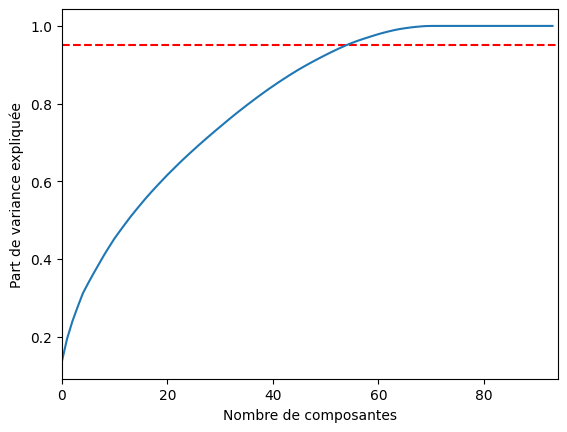

In [30]:
# Nombre de composantes pour 95% dela variance expliquée cumulée:
plt.figure()
plt.xlim(0,94)
plt.xlabel('Nombre de composantes')
plt.ylabel('Part de variance expliquée')
plt.axhline(y = 0.95, color ='r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

In [31]:
# On en précisant directement en PCA:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)

In [32]:
X_train_pca.shape

(20569, 55)

In [33]:
pca.components_.shape

(55, 94)

In [34]:
pca.components_

array([[-0.16100865,  0.17365911,  0.14913344, ...,  0.20218722,
        -0.20218722,  0.20218722],
       [-0.0003179 , -0.17381533, -0.09641116, ...,  0.12616434,
        -0.12616434,  0.12616434],
       [ 0.0559645 ,  0.0084079 , -0.00364227, ...,  0.19727949,
        -0.19727949,  0.19727949],
       ...,
       [ 0.11080802,  0.01057713, -0.17317141, ..., -0.05240455,
         0.05240455, -0.05240455],
       [ 0.07412126, -0.08095244,  0.03774352, ...,  0.03529125,
        -0.03529125,  0.03529125],
       [-0.27800727, -0.11742335, -0.0106019 , ..., -0.01172895,
         0.01172895, -0.01172895]], shape=(55, 94))

In [35]:
feature_contribution = pca.components_.T* np.sqrt(pca.explained_variance_)

In [36]:
feature_contribution.shape

(94, 55)

In [37]:
df_feature_contribution = pd.DataFrame(data=feature_contribution, index = X_train.columns)

In [38]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,-5.525755e-01,-7.225618e-04,1.102349e-01,-3.074088e-02,1.519663e-02,-3.669850e-02,-1.510382e-01,-5.116196e-02,6.008046e-02,1.181497e-01,...,-8.948384e-02,1.704994e-02,0.023952,-3.303960e-01,1.742845e-01,-3.303432e-01,1.426836e-01,8.343551e-02,5.484137e-02,-2.002125e-01
surface,5.959914e-01,-3.950702e-01,1.656130e-02,3.175748e-01,-1.647088e-01,8.681998e-02,-1.651111e-01,3.450946e-02,8.828144e-03,-2.505691e-02,...,-1.384947e-02,1.112195e-03,-0.037671,7.787265e-02,-3.343941e-02,2.757653e-02,-3.405661e-02,7.964299e-03,-5.989567e-02,-8.456477e-02
surface_terrain,5.118202e-01,-2.191359e-01,-7.174292e-03,1.218496e-01,-1.413086e-02,1.675723e-02,-2.122340e-01,3.497216e-02,-4.768682e-02,9.635400e-04,...,-9.173111e-02,-1.689268e-01,0.051860,-2.032196e-01,2.580185e-01,7.150896e-02,-2.678716e-01,-1.303935e-01,2.792594e-02,-7.635167e-03
nb_pieces,6.247306e-01,-4.019202e-01,-1.579520e-02,3.472805e-01,-1.668895e-01,6.188408e-02,-1.796133e-01,4.591156e-02,1.774676e-02,-2.465481e-02,...,-6.908270e-02,2.359420e-02,-0.030944,6.387182e-02,-3.269559e-02,5.202419e-02,-1.554462e-03,1.772170e-02,-6.555970e-02,-8.214550e-02
mensualiteFinance,-1.488376e-18,2.365744e-17,-3.280258e-16,-1.876734e-16,-3.038872e-17,-6.258036e-17,-8.122888e-17,1.199269e-16,3.981720e-17,1.534390e-16,...,-1.759321e-16,1.198383e-16,-0.000000,6.628556e-17,-5.487975e-17,-3.239618e-16,-3.082709e-16,2.680977e-16,-1.373345e-16,8.994930e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,1.089972e-02,2.006076e-02,-5.607959e-02,1.907659e-02,2.696464e-02,-2.936398e-02,3.171731e-02,-3.373826e-02,-3.003168e-04,-2.283787e-02,...,-7.737838e-03,4.806063e-02,0.038106,3.363649e-02,-1.670085e-03,8.147438e-03,-9.447604e-03,8.846809e-03,-4.927393e-03,-2.823790e-03
TYP_IRIS_x_H,-6.944878e-01,-2.878461e-01,-3.855598e-01,3.289805e-01,-2.089866e-01,-1.499926e-01,1.658691e-01,5.447879e-02,-1.337150e-01,1.087427e-01,...,-1.889237e-03,-6.382297e-02,-0.041125,9.450348e-03,-1.448902e-02,-2.611792e-02,1.011952e-03,3.898164e-02,-2.584553e-02,8.599303e-03
TYP_IRIS_x_Z,6.938988e-01,2.867628e-01,3.885872e-01,-3.300102e-01,2.075306e-01,1.515778e-01,-1.675813e-01,-5.265723e-02,1.337311e-01,-1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,-1.126636e-02,1.457917e-02,2.567802e-02,-5.018778e-04,-3.945924e-02,2.611154e-02,-8.446840e-03
TYP_IRIS_y_H,-6.938988e-01,-2.867628e-01,-3.885872e-01,3.300102e-01,-2.075306e-01,-1.515778e-01,1.675813e-01,5.265723e-02,-1.337311e-01,1.075096e-01,...,-2.306999e-03,-6.122814e-02,-0.039068,1.126636e-02,-1.457917e-02,-2.567802e-02,5.018778e-04,3.945924e-02,-2.611154e-02,8.446840e-03


In [39]:
df_feature_contribution = df_feature_contribution.abs()

In [40]:
df_feature_contribution

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
etage,5.525755e-01,7.225618e-04,1.102349e-01,3.074088e-02,1.519663e-02,3.669850e-02,1.510382e-01,5.116196e-02,6.008046e-02,1.181497e-01,...,8.948384e-02,1.704994e-02,0.023952,3.303960e-01,1.742845e-01,3.303432e-01,1.426836e-01,8.343551e-02,5.484137e-02,2.002125e-01
surface,5.959914e-01,3.950702e-01,1.656130e-02,3.175748e-01,1.647088e-01,8.681998e-02,1.651111e-01,3.450946e-02,8.828144e-03,2.505691e-02,...,1.384947e-02,1.112195e-03,0.037671,7.787265e-02,3.343941e-02,2.757653e-02,3.405661e-02,7.964299e-03,5.989567e-02,8.456477e-02
surface_terrain,5.118202e-01,2.191359e-01,7.174292e-03,1.218496e-01,1.413086e-02,1.675723e-02,2.122340e-01,3.497216e-02,4.768682e-02,9.635400e-04,...,9.173111e-02,1.689268e-01,0.051860,2.032196e-01,2.580185e-01,7.150896e-02,2.678716e-01,1.303935e-01,2.792594e-02,7.635167e-03
nb_pieces,6.247306e-01,4.019202e-01,1.579520e-02,3.472805e-01,1.668895e-01,6.188408e-02,1.796133e-01,4.591156e-02,1.774676e-02,2.465481e-02,...,6.908270e-02,2.359420e-02,0.030944,6.387182e-02,3.269559e-02,5.202419e-02,1.554462e-03,1.772170e-02,6.555970e-02,8.214550e-02
mensualiteFinance,1.488376e-18,2.365744e-17,3.280258e-16,1.876734e-16,3.038872e-17,6.258036e-17,8.122888e-17,1.199269e-16,3.981720e-17,1.534390e-16,...,1.759321e-16,1.198383e-16,0.000000,6.628556e-17,5.487975e-17,3.239618e-16,3.082709e-16,2.680977e-16,1.373345e-16,8.994930e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TYP_IRIS_x_D,1.089972e-02,2.006076e-02,5.607959e-02,1.907659e-02,2.696464e-02,2.936398e-02,3.171731e-02,3.373826e-02,3.003168e-04,2.283787e-02,...,7.737838e-03,4.806063e-02,0.038106,3.363649e-02,1.670085e-03,8.147438e-03,9.447604e-03,8.846809e-03,4.927393e-03,2.823790e-03
TYP_IRIS_x_H,6.944878e-01,2.878461e-01,3.855598e-01,3.289805e-01,2.089866e-01,1.499926e-01,1.658691e-01,5.447879e-02,1.337150e-01,1.087427e-01,...,1.889237e-03,6.382297e-02,0.041125,9.450348e-03,1.448902e-02,2.611792e-02,1.011952e-03,3.898164e-02,2.584553e-02,8.599303e-03
TYP_IRIS_x_Z,6.938988e-01,2.867628e-01,3.885872e-01,3.300102e-01,2.075306e-01,1.515778e-01,1.675813e-01,5.265723e-02,1.337311e-01,1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,1.126636e-02,1.457917e-02,2.567802e-02,5.018778e-04,3.945924e-02,2.611154e-02,8.446840e-03
TYP_IRIS_y_H,6.938988e-01,2.867628e-01,3.885872e-01,3.300102e-01,2.075306e-01,1.515778e-01,1.675813e-01,5.265723e-02,1.337311e-01,1.075096e-01,...,2.306999e-03,6.122814e-02,0.039068,1.126636e-02,1.457917e-02,2.567802e-02,5.018778e-04,3.945924e-02,2.611154e-02,8.446840e-03


In [41]:
df_feature_contribution['mean_contribution'] = df_feature_contribution.mean(axis=1)

In [42]:
df_feature_contribution['mean_contribution'].sort_values(ascending=False)

dpe_B                     1.087458e-01
Latitude_scaled           1.084276e-01
ges_G                     1.075901e-01
ges_A                     1.057258e-01
dpe_G                     1.048555e-01
                              ...     
REG                       7.692062e-17
energie_inconnue          4.775794e-17
chauf_inconnu             4.045755e-17
chauffage_mode_inconnu    2.087458e-17
type_annonceur_pr         1.068918e-17
Name: mean_contribution, Length: 94, dtype: float64

In [43]:
# Pour différentes valeurs d'un seuil de contribution, on regarde combien de features on garderait

for threshold in [0.1, 0.08, 0.06, 0.04, 0.02, 0.01]:
    feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > threshold]
    index_selected = feature_selected.index
    print(f"seuil: {threshold}, nombre de features selectionnées: {len(index_selected)}")

seuil: 0.1, nombre de features selectionnées: 13
seuil: 0.08, nombre de features selectionnées: 48
seuil: 0.06, nombre de features selectionnées: 78
seuil: 0.04, nombre de features selectionnées: 87
seuil: 0.02, nombre de features selectionnées: 87
seuil: 0.01, nombre de features selectionnées: 87


In [44]:
feature_selected = df_feature_contribution[df_feature_contribution['mean_contribution'] > 0.06]
features_selected_pca = list(feature_selected.index)
features_selected_pca

['etage',
 'surface',
 'surface_terrain',
 'nb_pieces',
 'balcon',
 'eau',
 'bain',
 'dpeC',
 'nb_etages',
 'places_parking',
 'cave',
 'annee_construction',
 'nb_toilettes',
 'nb_logements_copro',
 'charges_copro',
 'logement_neuf',
 'IRIS',
 'prix_m2_vente',
 'Latitude_scaled',
 'Longitude_scaled',
 'prix_bien_target_encoding',
 'annee_2019',
 'annee_2020',
 'annee_2021',
 'annee_2022',
 'annee_2023',
 'expo_nord',
 'expo_sud',
 'expo_est',
 'expo_ouest',
 'expo_inconnue',
 'chauf_radiateur',
 'chauf_sol',
 'chauf_convecteur',
 'chauf_poele_bois',
 'chauf_pac',
 'chauf_clim_rev',
 'chauf_cheminee',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'energie_bois',
 'dpe_A',
 'dpe_B',
 'dpe_C',
 'dpe_D',
 'dpe_E',
 'dpe_F',
 'dpe_G',
 'dpe_inconnu',
 'ges_A',
 'ges_B',
 'ges_C',
 'ges_D',
 'ges_E',
 'ges_F',
 'ges_G',
 'ges_inconnu',
 'chauffage_mode_individuel',
 'chauffage_mode_collectif',
 'chauffage_mode_central',
 'typedetransaction_pi',
 'typedetransaction_v',
 'typedetransacti

## 14.3) Matthieu

### 14.3.1) Backward Elimination

LinearRegression sur l'ensemble des Features

In [45]:
# Modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédictions
y_pred = lr.predict(X_test)

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985


In [46]:
len(lr.coef_[0])

94

Coefficients des Features

In [47]:
import pandas as pd

# Création du dictionnaire avec les coefficients absolus
columns_coef = dict(zip(X_train.columns, np.abs(lr.coef_[0]).tolist()))

# Tri par ordre décroissant des coefficients
columns_coef_trie = dict(sorted(columns_coef.items(), key=lambda item: item[1], reverse=True))

# Création du DataFrame avec l'ordre, la feature et le coefficient
df_resultats = pd.DataFrame([
    {'Ordre d\'importance': i, 'Feature': feature, 'Coefficient en valeur absolue': coef}
    for i, (feature, coef) in enumerate(columns_coef_trie.items(), start=1)
])

# Affichage du DataFrame
df_resultats.head(10)


,Ordre d'importance,Feature,Coefficient en valeur absolue
0,1,surface,101690.270683
1,2,prix_m2_vente,96291.434537
2,3,prix_bien_target_encoding,40609.028414
3,4,nb_pieces,17839.449118
4,5,surface_terrain,7787.940575
5,6,ascenseur,7657.392469
6,7,Longitude_scaled,5930.848221
7,8,IRIS,5346.676171
8,9,UU2010,5313.970229
9,10,categorie_annonceur_cm,5253.494794


In [48]:
features_selected_lr = df_resultats['Feature'].tolist()
features_selected_lr

['surface',
 'prix_m2_vente',
 'prix_bien_target_encoding',
 'nb_pieces',
 'surface_terrain',
 'ascenseur',
 'Longitude_scaled',
 'IRIS',
 'UU2010',
 'categorie_annonceur_cm',
 'logement_neuf',
 'energie_gaz',
 'energie_elec',
 'energie_fioul',
 'bain',
 'dpe_A',
 'chauf_sol',
 'chauffage_mode_collectif',
 'expo_sud',
 'charges_copro',
 'dpeC',
 'annee_construction',
 'typedebien_lite_m',
 'typedebien_a',
 'typedebien_m',
 'typedebien_lite_a',
 'chauffage_mode_individuel',
 'dpe_inconnu',
 'expo_inconnue',
 'ges_inconnu',
 'categorie_annonceur_ca',
 'eau',
 'categorie_annonceur_a',
 'categorie_annonceur_b',
 'nb_toilettes',
 'dpe_C',
 'etage',
 'ges_A',
 'categorie_annonceur_network',
 'chauf_pac',
 'annonce_exclusive_Non',
 'dpe_F',
 'energie_bois',
 'ges_E',
 'typedetransaction_v',
 'cave',
 'typedetransaction_vp',
 'dpe_D',
 'categorie_annonceur_m',
 'annonce_exclusive_Oui',
 'Latitude_scaled',
 'nb_logements_copro',
 'ges_C',
 'dpe_G',
 'dpe_E',
 'nb_etages',
 'annee_2019',
 'ges_B

<Axes: >

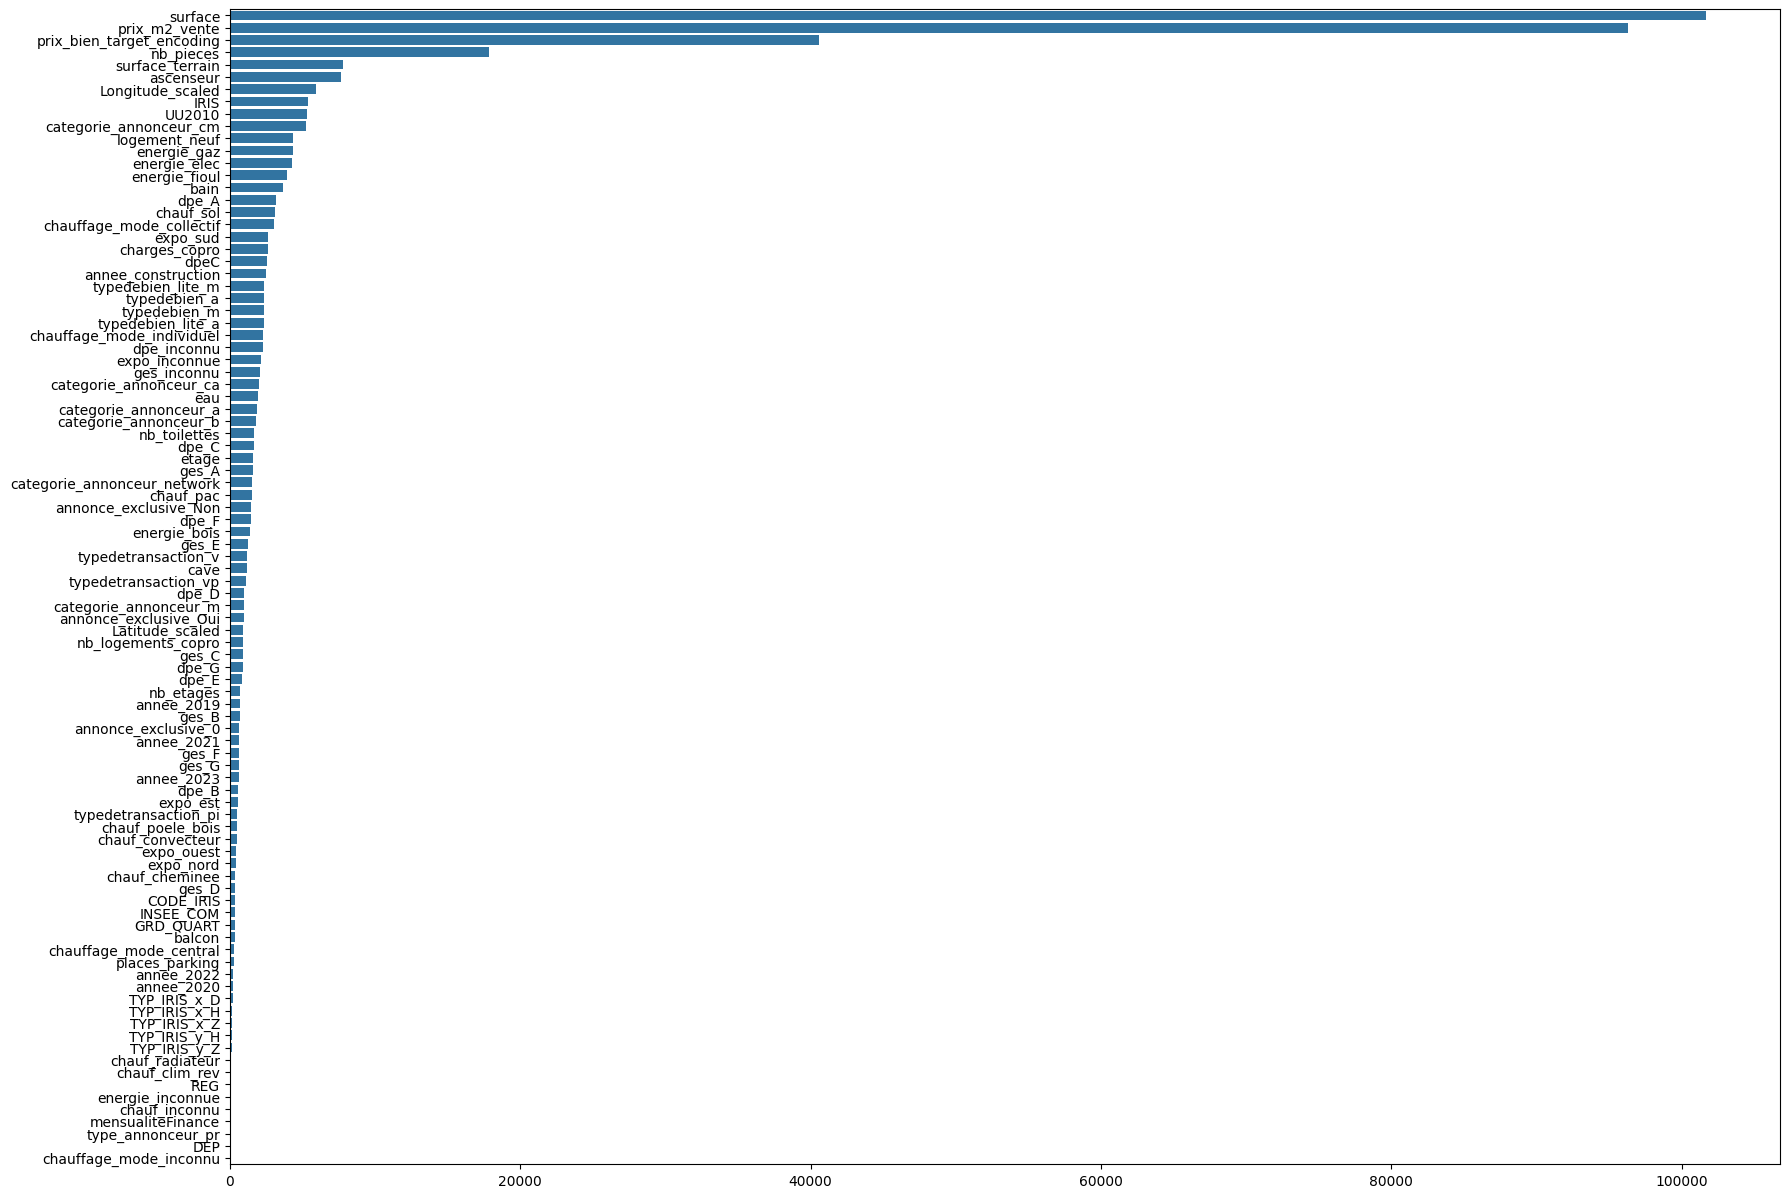

In [49]:
fig, ax = plt.subplots(figsize = (20,15))
sns.barplot(x=columns_coef_trie.values(), y=columns_coef_trie.keys())

LinearRegression en ne gardant que les 10 plus gros coefficient

In [50]:
lr = LinearRegression()
lr.fit(X_train[df_resultats.Feature[:10].values.tolist()], y_train)

# Prédictions
y_pred = lr.predict(X_test[df_resultats.Feature[:10].values.tolist()])

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 32778.69
RMSE : 52717.45
R2   : 0.8903


SequentialFeatureSelector (backward)

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'eau', 'bain',
       'dpeC', 'cave', 'annee_construction', 'nb_toilettes', 'ascenseur',
       'charges_copro', 'logement_neuf', 'IRIS', 'GRD_QUART', 'UU2010',
       'prix_m2_vente', 'Latitude_scaled', 'Longitude_scaled',
       'prix_bien_target_encoding', 'annee_2023', 'expo_sud', 'expo_est',
       'expo_inconnue', 'chauf_sol', 'chauf_pac', 'energie_gaz', 'dpe_B',
       'dpe_C', 'dpe_D', 'dpe_E', 'dpe_F', 'dpe_G', 'dpe_inconnu', 'ges_B',
       'ges_C', 'ges_D', 'ges_G', 'ges_inconnu', 'chauffage_mode_collectif',
       'typedetransaction_pi', 'typedetransaction_vp', 'annonce_exclusive_Non',
       'categorie_annonceur_b', 'categorie_annonceur_cm',
       'categorie_annonceur_network', 'typedebien_lite_a'],
      dtype='object')
MAE  : 31497.50
RMSE : 50755.38
R2   : 0.8983


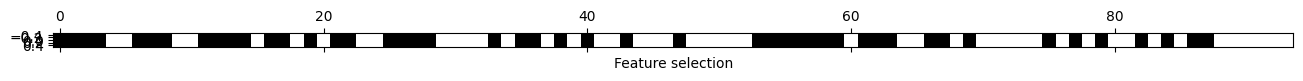

In [51]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# Modèle
lr = LinearRegression()

# Backward Selection (recul)
sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction="backward",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_squared_error"
)

sfs.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = sfs.get_support()
selected_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", selected_features)

# Modèle final sur features retenues
lr.fit(X_train[selected_features], y_train)
y_pred = lr.predict(X_test[selected_features])

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


In [52]:
features_selected_sfs = selected_features
len(features_selected_sfs)

47

SelectKBest

Features retenues : Index(['etage', 'surface', 'surface_terrain', 'nb_pieces', 'balcon', 'eau',
       'bain', 'dpeC', 'nb_etages', 'places_parking', 'nb_toilettes',
       'ascenseur', 'nb_logements_copro', 'charges_copro', 'logement_neuf',
       'IRIS', 'UU2010', 'prix_m2_vente', 'Longitude_scaled',
       'prix_bien_target_encoding', 'annee_2020', 'annee_2022', 'annee_2023',
       'energie_gaz', 'energie_elec', 'energie_fioul', 'dpe_A', 'dpe_B',
       'dpe_E', 'ges_A', 'chauffage_mode_individuel',
       'chauffage_mode_collectif', 'typedebien_a', 'typedebien_m',
       'typedetransaction_v', 'typedetransaction_vp', 'annonce_exclusive_0',
       'annonce_exclusive_Oui', 'categorie_annonceur_a',
       'categorie_annonceur_cm', 'typedebien_lite_a', 'typedebien_lite_m',
       'TYP_IRIS_x_H', 'TYP_IRIS_x_Z', 'TYP_IRIS_y_H', 'TYP_IRIS_y_Z'],
      dtype='object')
MAE  : 31901.39
RMSE : 51343.13
R2   : 0.8959


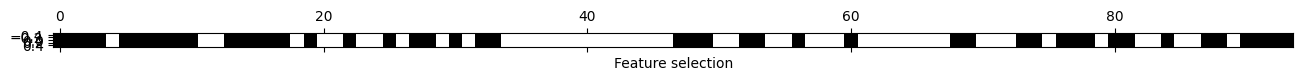

In [53]:
from sklearn.feature_selection import SelectKBest, f_regression

# Choix de K
k = 46

# SelectKBest
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_train, y_train.values.ravel())

# Colonnes retenues
mask = selector.get_support()
kbest_features = X_train.columns[mask]

plt.matshow(mask.reshape(1,-1), cmap = 'gray_r')
plt.xlabel('Feature selection');

print("Features retenues :", kbest_features)

# Modèle final
lr = LinearRegression()
lr.fit(X_train[kbest_features], y_train)

y_pred = lr.predict(X_test[kbest_features])

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


L'écart de perf entre le modèle prenant l'ensemble des Features et les modèles prenant les 20 features portant le plus d'information est très très faible.

In [54]:
features_selected_kbest = kbest_features
len(features_selected_kbest)

46

In [55]:
selected_dict = { 'pca': features_selected_pca,
                  'lr': features_selected_lr,
                  'sfs': features_selected_sfs,
                  'kbest': features_selected_kbest}

In [56]:
import joblib

joblib.dump(selected_dict, "selected_dict.joblib")

['selected_dict.joblib']

## 14.4) Intersection

In [57]:
#si l'on regarde l'intersection entre les 30 features sélectionnées par la PCA et les 30 sélectionnées par la lr:
selected = set(selected_dict['pca'][:46]).intersection(set(selected_dict['lr'][:46])).intersection(set(selected_dict['sfs'])).intersection(set(selected_dict['kbest']))
selected = list(selected)
selected

['logement_neuf',
 'nb_pieces',
 'IRIS',
 'prix_bien_target_encoding',
 'etage',
 'charges_copro',
 'energie_gaz',
 'prix_m2_vente',
 'dpeC',
 'eau',
 'Longitude_scaled',
 'surface_terrain',
 'nb_toilettes',
 'surface',
 'bain']

In [58]:
len(selected)

15

In [59]:
# Si on essaie une régression avec ces 5 features:
lr = LinearRegression()
lr.fit(X_train[selected], y_train)

# Prédictions
y_pred = lr.predict(X_test[selected])

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 33038.27
RMSE : 53103.04
R2   : 0.8887


### On est un peu moins bien que pour uniquement les 15 features mais on est sur un seul type de modèle (régression linéaire). On verra par la suite avec les autres modèles et en optimisant ce que l'on obtiendra...

In [60]:
y_pred = pd.DataFrame(data = y_pred, index=y_test.index)

In [61]:
y_pred = y_pred.rename(columns={0: "prix_bien"})

In [62]:
diff = y_test - y_pred

In [63]:
y_test

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,115400
ag680297-277810664,106500
orpi-1-054041E1OWKF,118250
guy-hoquet-immo-facile-6243822,76000
ag440414-293552741,390000
...,...
immo-facile-35871425,100000
ag680254-273036872,210000
ag681158-373018354,72000


In [64]:
y_pred

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,171031.329178
ag680297-277810664,79130.964170
orpi-1-054041E1OWKF,89105.674323
guy-hoquet-immo-facile-6243822,45245.743635
ag440414-293552741,354738.620538
...,...
immo-facile-35871425,84732.066144
ag680254-273036872,232467.433558
ag681158-373018354,41700.313097


In [65]:
y_test.loc['ag681120-337284537', 'prix_bien']

np.int64(2300000)

In [66]:
diff

,prix_bien
idannonce,
guy-hoquet-immo-facile-5974993,-55631.329178
ag680297-277810664,27369.035830
orpi-1-054041E1OWKF,29144.325677
guy-hoquet-immo-facile-6243822,30754.256365
ag440414-293552741,35261.379462
...,...
immo-facile-35871425,15267.933856
ag680254-273036872,-22467.433558
ag681158-373018354,30299.686903


In [67]:
diff.idxmax()

prix_bien    ag681120-337284537
dtype: object

In [68]:
diff.loc['ag681120-337284537']

prix_bien    1.020508e+06
Name: ag681120-337284537, dtype: float64

In [69]:
print(f"prediction: {int(y_pred.loc['ag681120-337284537', 'prix_bien'])}, prix réel: {y_test.loc['ag681120-337284537', 'prix_bien']}")

prediction: 1279491, prix réel: 2300000


In [70]:
df_ventes.loc['ag681120-337284537']

type_annonceur                    pr
typedebien                         m
typedetransaction                  v
etage                              0
surface                          354
surface_terrain               1300.0
nb_pieces                          8
prix_bien                    2300000
mensualiteFinance                  0
balcon                             0
eau                                0
bain                               0
dpeL                               B
dpeC                            89.0
mapCoordonneesLatitude      47.49404
mapCoordonneesLongitude      7.48269
annonce_exclusive                Non
nb_etages                       <NA>
places_parking                  <NA>
cave                            <NA>
exposition                         0
ges_class                          B
annee_construction              <NA>
nb_toilettes                    <NA>
ascenseur                       <NA>
nb_logements_copro              <NA>
charges_copro                    NaN
c

# 15) Focus sur les 'mauvaises' prédictions

In [84]:
df_diff_geo = pd.merge(diff.sort_values(by='prix_bien', ascending=False), df_ventes[['typedebien', 'mapCoordonneesLongitude', 'mapCoordonneesLatitude']], how='left', left_index=True, right_index=True)
df_diff_geo = df_diff_geo.rename(columns={"prix_bien": "delta_prediction"})

In [85]:
df_diff_geo.head()

,delta_prediction,typedebien,mapCoordonneesLongitude,mapCoordonneesLatitude
idannonce,,,,
ag681120-337284537,1.020508e+06,m,7.48269,47.49404
immo-facile-51101837,6.096227e+05,m,7.34499,48.06013
hektor-dagon68390-2443,4.267085e+05,m,7.19852,47.90230
immo-facile-40221393,3.705944e+05,m,7.35363,48.06911
ag681140-373012054,3.554623e+05,m,7.32489,48.19246


In [109]:
import folium
from folium import LayerControl
import numpy as np

# Définir le nombre de groupes
nb_groupes = 5

# Calculer min et max
min_val = df_diff_geo['delta_prediction'].min()
max_val = df_diff_geo['delta_prediction'].max()

# Définir les intervalles pour négatifs et positifs
# Si min est négatif, on divise en 5 intervalles négatifs
if min_val < 0:
    interval_neg = abs(min_val) / nb_groupes
    seuils_neg = [-np.inf] + [min_val + i * interval_neg for i in range(1, nb_groupes)] + [0]
else:
    seuils_neg = [-np.inf, 0]  # pas de négatifs

# Si max est positif, on divise en 5 intervalles positifs
if max_val > 0:
    interval_pos = max_val / nb_groupes
    seuils_pos = [0] + [i * interval_pos for i in range(1, nb_groupes)] + [np.inf]
else:
    seuils_pos = [0, np.inf]  # pas de positifs

# Définir les teintes de bleu et rouge
teintes_bleu = ['#deebf7', '#9ecae1', '#6baed6', '#3182bd', '#08519c'][::-1]
teintes_rouge = ['#fee0d2', '#fc9272', '#fb6a4a', '#de2d26', '#a50f15']

# Créer la carte
m = folium.Map(
    location=lat_long_mean,
    tiles="Cartodb Positron",
    min_lat=min_lat,
    min_lon=min_lon,
    max_lat=max_lat,
    max_lon=max_lon,
    zoom_control=True,
    zoom_start=10
)

# Créer des groupes pour chaque groupe
groupes = {}
for i in range(nb_groupes):
    groupes[f'Negatif {i+1}'] = folium.FeatureGroup(name=f'Negatif {i+1}').add_to(m)
for i in range(nb_groupes):
    groupes[f'Positif {i+1}'] = folium.FeatureGroup(name=f'Positif {i+1}').add_to(m)

# Fonction pour déterminer le groupe négatif
def get_groupe_neg(val):
    for i in range(nb_groupes):
        if val >= seuils_neg[i] and val <= seuils_neg[i+1]:
            return f'Negatif {i+1}', teintes_bleu[i]
    return None, None

# Fonction pour déterminer le groupe positif
def get_groupe_pos(val):
    for i in range(nb_groupes):
        if val >= seuils_pos[i] and val <= seuils_pos[i+1]:
            return f'Positif {i+1}', teintes_rouge[i]
    return None, None

# Ajout des marqueurs
for index, row in df_diff_geo.iterrows():
    val = row['delta_prediction']
    lat = row['mapCoordonneesLatitude']
    lon = row['mapCoordonneesLongitude']
    if val < 0:
        groupe, couleur = get_groupe_neg(val)
        if groupe is None:
            couleur = '#deebf7'
        groupe = groupe
    elif val > 0:
        groupe, couleur = get_groupe_pos(val)
        if groupe is None:
            couleur = '#fee0d2'
        groupe = groupe
    else:
        groupe = 'Prédiction = 0'
        couleur = '#ffffff'  # blanc

    # Ajouter le marqueur
    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        stroke=False,
        fill=True,
        fill_opacity=0.6,
        opacity=1,
        fill_color=couleur,
        color=couleur,
        popup=f"Delta prediction: {val}"
    ).add_to(groupes[groupe])

# Ajoute la layer control
LayerControl().add_to(m)

# Enregistrer ou afficher
m

# 16) Modélisation

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Modèle
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédictions
y_pred = lr.predict(X_test)

# Scores
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 31428.47
RMSE : 50699.14
R2   : 0.8985
